In [16]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict


In [34]:
class PercentageMark(TypedDict):
    total_marks : float
    obtained_marks:float
    percent_marks:float

In [46]:
def take_percentage(state: PercentageMark):
    total_marks = state['total_marks']
    obtained_marks = state['obtained_marks']
    percent_marks = (obtained_marks / total_marks)*100
    state['percent_marks'] = percent_marks 
    return state

{'total_marks': 1100.0, 'obtained_marks': 945.0, 'percent_marks': 85.9090909090909}


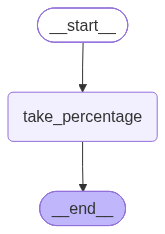

In [48]:
graph = StateGraph(PercentageMark)

# add graph nodes to graph
graph.add_node('take_percentage',take_percentage)

# add edges nodes to graph
graph.add_edge(START,"take_percentage")
graph.add_edge("take_percentage",END)

# compile 
workflow = graph.compile()

# execute
inital_state : PercentageMark = {"total_marks":1100.0,"obtained_marks":945.0,"percent_marks":" "} 
final_state = workflow.invoke(inital_state)

print(final_state)
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())